<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install --upgrade --force-reinstall numpy pandas matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/1

In [1]:
!pip install "numpy<=2.0.0" "Pillow<11.2" "langchain==0.2.16" "langchain-core==0.2.41" "langchain-community==0.2.17"

In [2]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu-cu12 openpyxl datasets langchain-community ragatouille umap-learn bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180

In [3]:
!pip install -q --upgrade ragatouille

In [4]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel
from langchain.text_splitter import RecursiveCharacterTextSplitter
from sklearn.metrics.pairwise import cosine_similarity

/tmp/ipykernel_6511/1320287451.py:17: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Загрузка данных (4 балла)

In [6]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=058ad817-7e73-49ac-873c-03352a0adf5c
To: /content/file.csv
100%|██████████| 672M/672M [00:07<00:00, 89.1MB/s]


In [7]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [8]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [9]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

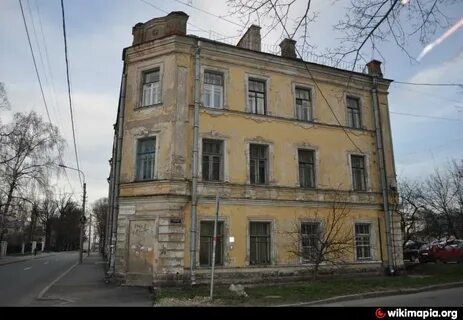

In [10]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Обработаем датасет

In [11]:
df = data.copy()
df = df.fillna("")

In [12]:
df["full_text"] = (df["description"].astype(str) + " " + df["en_txt"].astype(str)).str.strip()


In [13]:
from bertopic import BERTopic

In [14]:
embedding_model_bt = SentenceTransformer("intfloat/multilingual-e5-small",device=device)

texts = df["full_text"].tolist()
embeddings_bt = embedding_model_bt.encode(texts, show_progress_bar=True, normalize_embeddings=True)


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/458 [00:00<?, ?it/s]

In [15]:
topic_model = BERTopic(
    embedding_model=embedding_model_bt,
    language="multilingual",
    min_topic_size=20,
    nr_topics="auto",
    verbose=True,
)

topics, probs = topic_model.fit_transform(texts, embeddings_bt)
df["topic"] = topics

print(f"Найдено топиков: {len(set(topics)) - 1}")
print(f"Выбросов (topic=-1): {(df['topic'] == -1).sum()}")


2026-05-04 18:33:13,621 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 18:33:59,109 - BERTopic - Dimensionality - Completed ✓
2026-05-04 18:33:59,111 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 18:34:00,011 - BERTopic - Cluster - Completed ✓
2026-05-04 18:34:00,013 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-04 18:34:00,416 - BERTopic - Representation - Completed ✓
2026-05-04 18:34:00,417 - BERTopic - Topic reduction - Reducing number of topics
2026-05-04 18:34:00,538 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 18:34:00,739 - BERTopic - Representation - Completed ✓
2026-05-04 18:34:00,743 - BERTopic - Topic reduction - Reduced number of topics from 229 to 55


Найдено топиков: 54
Выбросов (topic=-1): 3147


In [16]:
topic_model.get_topic_info().head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3147,-1_of_on_with_ярославле,"[of, on, with, ярославле, in, and, arafed, the...",[arafed view of a building with a clock on the...
1,0,9287,0_with_building_arafed_of,"[with, building, arafed, of, and, view, large,...",[Храм в Ярославле there is a large building wi...
2,1,120,1_painting_close_poster_up,"[painting, close, poster, up, picture, easel, ...",[painting of a painting of a city with a churc...
3,2,110,2_военное_uniform_высшее_училище,"[военное, uniform, высшее, училище, россии, so...",[высшее военное училище в России soldiers in u...
4,3,105,3_children_standing_several_are,"[children, standing, several, are, table, sitt...",[there are many children standing in a room wi...
5,4,65,4_glass_vases_case_display,"[glass, vases, case, display, many, different,...",[there are many glass vases on display in a gl...
6,5,63,5_зоопарк_bear_ярославский_ball,"[зоопарк, bear, ярославский, ball, teddy, zoo,...",[Ярославский зоопарк there is a large teddy be...
7,6,60,6_33_карла_маркса_школа,"[33, карла, маркса, школа, имени, sign, buildi...",[Школа № 33 имени Карла Маркса there is a larg...
8,7,59,7_фёдору_толбухину_uniform_military,"[фёдору, толбухину, uniform, military, ярослав...",[Памятник Фёдору Толбухину (Ярославль) a black...
9,8,58,8_беседка_набережной_gazebo_волжской,"[беседка, набережной, gazebo, волжской, на, ov...",[Беседка на Волжской набережной there is a gaz...


In [17]:
topic_model.visualize_barchart(top_n_topics=15, n_words=8)

In [18]:
topic_model.visualize_documents(texts, embeddings=embeddings_bt, hide_annotations=True)

In [19]:
def inspect_topic(topic_id, n=2):
    subset = df[df["topic"] == topic_id]
    subset = subset.sample(min(n, len(subset)), random_state=42)
    for _, row in subset.iterrows():
        print(f"📍 {row['Name']} | {row['City']}")
        print(f"   desc: {row['description'][:120]}")
        print(f"   blip: {row['en_txt'][:120]}")
        display(get_image(row['image']))

📍 Церковь Ильи Пророка | Ярославль
   desc: Православный храм в Ярославле
   blip: arafed image of a church with a green roof and a blue sky


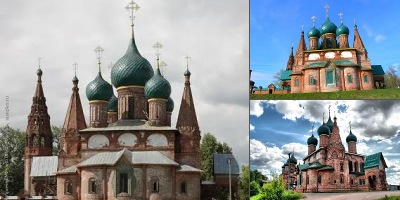

📍 Блиновский пассаж | Нижний Новгород
   desc: Блиновский пассаж
   blip: there are many people walking down the street in this old photo


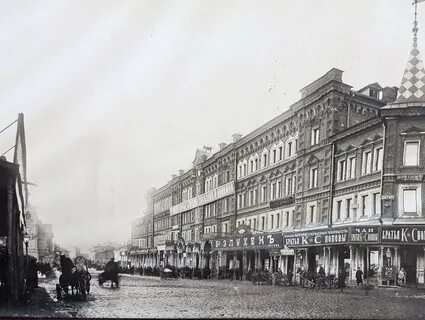

📍 Выставочный зал | Владимир
   desc: 
   blip: arafed statue of a woman holding a tennis racket in a museum


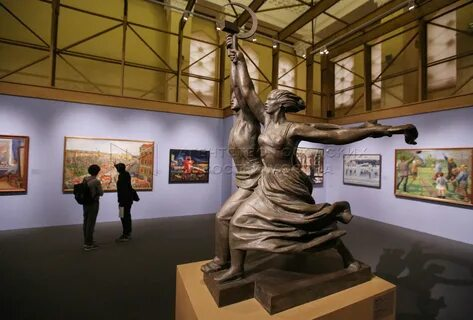


Topic 0 (9287 docs): with, building, arafed, of, and
📍 Дом-музей Бажова | Екатеринбург
   desc: Мемориальный дом-музей П. П. Бажова
   blip: there is a small wooden building with a red roof and a red tin roof


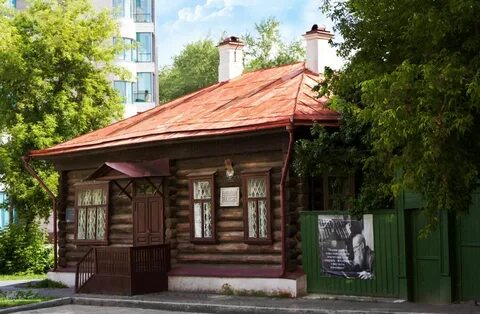

📍 Лебедев-Полянский П.И. | Владимир
   desc: 
   blip: arafed statue of a man with a beard in front of a building


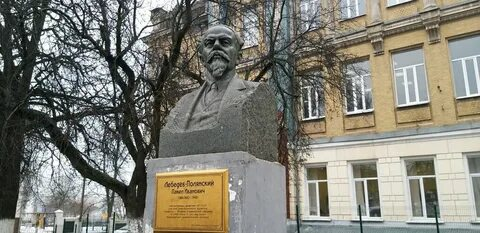


Topic 1 (120 docs): painting, close, poster, up, picture
📍 Панно на стене | Владимир
   desc: 
   blip: a painting of a tree and mountains with birds flying by


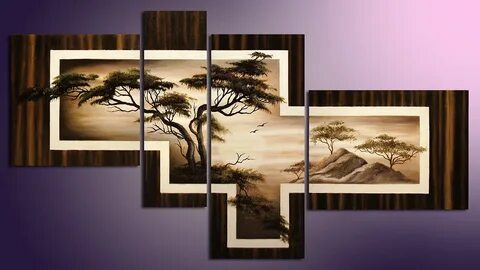

📍 Владимирская гвардейская ракетная Витебская Краснознамённая армия | Владимир
   desc: 
   blip: a close up of a patch with a red, white and blue design


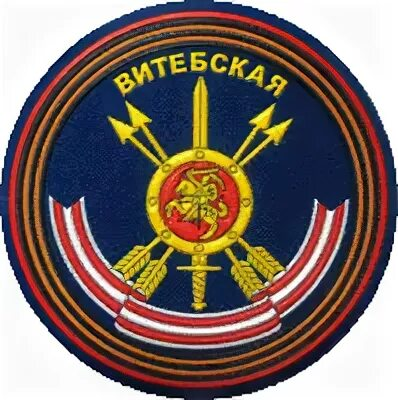


Topic 2 (110 docs): военное, uniform, высшее, училище, россии
📍 Ярославский филиал Военно-космической академии имени А. Ф. Можайского | Ярославль
   desc: высшее военное училище в России
   blip: araffes in uniform standing in a line in front of a building


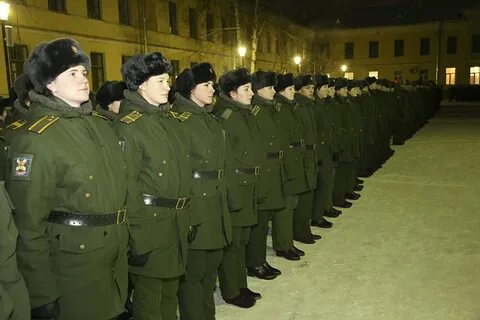

📍 Суворовское училище | Екатеринбург
   desc: военно-учебное заведение в Екатеринбурге
   blip: arafed group of men in military uniforms sitting in rows


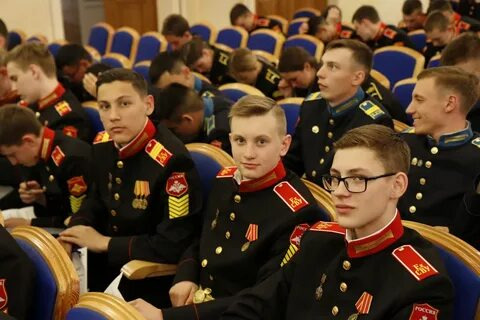


Topic 3 (105 docs): children, standing, several, are, table
📍 Огни Владимира | Владимир
   desc: 
   blip: there is a woman sitting on a bench in front of a wall


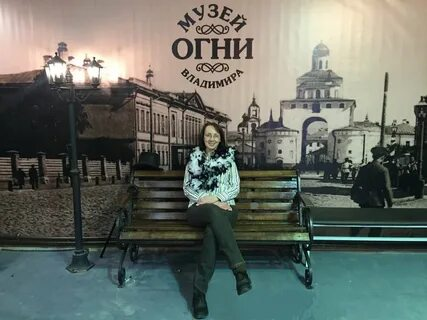

📍 Библиотечная лужайка | Владимир
   desc: 
   blip: there are two children sitting at a table with craft supplies


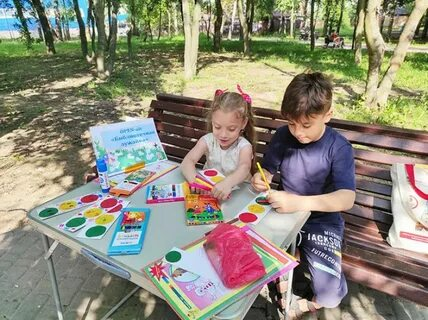

In [20]:
inspect_topic(-1, n=3)

for tid in range(0, min(4, len(set(topics)))):
    count = (df["topic"] == tid).sum()
    words = ", ".join([w for w, _ in topic_model.get_topic(tid)[:5]])
    print(f"\n{'='*60}")
    print(f"Topic {tid} ({count} docs): {words}")
    inspect_topic(tid, n=2)


In [21]:
NOISE_TOPICS = {-1}

df_clean = df[~df["topic"].isin(NOISE_TOPICS)].copy()
print(f"До очистки: {len(df)}, после: {len(df_clean)}")


До очистки: 14634, после: 11487


In [22]:
df_clean.head(3)

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt,full_text,topic
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...,спорткомплекс в Екатеринбурге there are two pe...,0
6,6,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,aerial view of a city with a soccer field and ...,спорткомплекс в Екатеринбурге aerial view of a...,0
11,11,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a city with a large building an...,спорткомплекс в Екатеринбурге arafed view of a...,0


In [23]:
def aggregate_place(group):
    best_desc = max(group["description"].tolist(), key=len)

    unique_captions = list(set(group["en_txt"].dropna().tolist()))[:3]

    return pd.Series({
        "description": best_desc,
        "en_txt_combined": " | ".join(unique_captions),
        "WikiData": group["WikiData"].iloc[0],
        "Lon": group["Lon"].iloc[0],
        "Lat": group["Lat"].iloc[0],
        "image": group["image"].iloc[0],
        "num_photos": len(group),
    })


In [24]:
grouped = df_clean.groupby(["City", "Name"]).apply(aggregate_place).reset_index()

grouped["full_text"] = grouped.apply(
    lambda r: f"{r['Name']} ({r['City']}). {r['description']}. На изображении: {r['en_txt_combined']}",
    axis=1
)
grouped.head(5)

,City,Name,description,en_txt_combined,WikiData,Lon,Lat,image,num_photos,full_text
0,Владимир,1941-1945,,there are two men sitting on a tank with a gun...,,40.362949,56.111187,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,17,1941-1945 (Владимир). . На изображении: there ...
1,Владимир,2000 летию Рождества Христова,,a close up of a painting of a man on a wall | ...,,40.408882,56.127674,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,23,2000 летию Рождества Христова (Владимир). . На...
2,Владимир,église arménienne de Vladimir,Армянская церковь в г. Владимир России,a close up of a planet with a star in the back...,Q18331756,40.456497,56.154667,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,29,église arménienne de Vladimir (Владимир). Армя...
3,Владимир,Авиамеханический колледж,Владимирский авиамеханический колледж,cars are driving down the street in front of a...,Q18786015,40.387318,56.126278,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,25,Авиамеханический колледж (Владимир). Владимирс...
4,Владимир,Аптекарь,,statue of a man holding a tray with a bottle a...,,40.402309,56.127251,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,16,Аптекарь (Владимир). . На изображении: statue ...


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [25]:
RAW_KNOWLEDGE_BASE = [
    LangchainDocument(
      page_content=row["full_text"],
        metadata={
          "source": row["WikiData"],
          "name": row["Name"],
          "city": row["City"],
          "coordinates": [row["Lon"], row["Lat"]],
        }
    )
    for _, row in tqdm(grouped.iterrows())
]

0it [00:00, ?it/s]

In [26]:
RAW_KNOWLEDGE_BASE[0]

Document(metadata={'source': '', 'name': '1941-1945', 'city': 'Владимир', 'coordinates': [40.362949, 56.111187]}, page_content='1941-1945 (Владимир). . На изображении: there are two men sitting on a tank with a gun | soldiers reading a newspaper in front of a tank | arafed view of a city with a lot of buildings and a lot of people')

Воспользуемся intfloat/multilingual-e5-small - она работает и с русским, и с английским языками

  0%|          | 0/1252 [00:00<?, ?it/s]

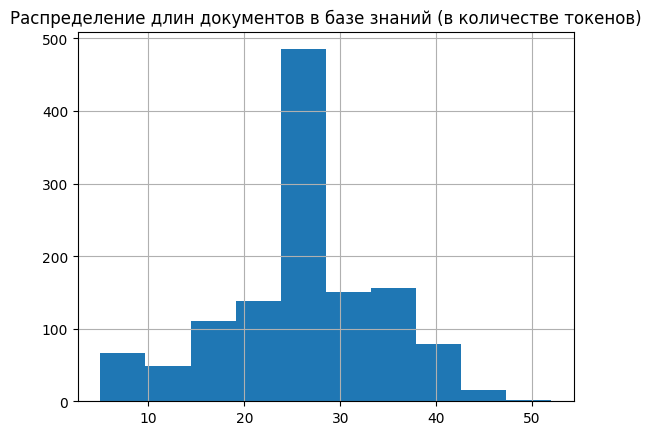

In [27]:
EMBEDDING_MODEL_NAME = 'intfloat/multilingual-e5-small'

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:
    """
    Разобъём документы на блоки максимального размера `chunk_size` и вернём список документов.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    # Удалим дубли
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


docs_processed = split_documents(
    100,  # Выбираем размер чанка, соответствующий модели
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=EMBEDDING_MODEL_NAME,
)

# Представим размеры блоков, которые возможно получить в токенах из общей модели
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

In [41]:
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=False,
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [42]:
user_query = "архитектура Нижнего Новгорода"
query_vector = embedding_model.embed_query(user_query)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [30]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
import umap

# Получаем эмбеддинги из FAISS и добавляем вектор запроса
embeddings = np.array([KNOWLEDGE_VECTOR_DATABASE.index.reconstruct_n(i, 1)[0]
                       for i in range(len(docs_processed))])
embeddings = np.vstack([embeddings, query_vector])

# Метки и текст для подсказки
labels = [doc.metadata["source"].split("/")[-1] for doc in docs_processed] + ["User query"]
extracts = [doc.page_content[:100] + "..." for doc in docs_processed] + [user_query]

def plot_embeddings_2d(embeddings_2d, title):
    df = pd.DataFrame({
        "x": embeddings_2d[:, 0],
        "y": embeddings_2d[:, 1],
        "source": labels,
        "extract": extracts,
        "symbol": ["circle"]*len(docs_processed) + ["star"],
        "size_col": [4]*len(docs_processed) + [100]
    })
    fig = px.scatter(
        df, x="x", y="y", color="source", hover_data="extract",
        size="size_col", symbol="symbol",
        color_discrete_map={"User query": "black"},
        width=1000, height=700, title=title
    )
    fig.update_traces(marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")))
    fig.update_layout(legend_title_text="<b>Источник чанка</b>")
    fig.show()

# PCA
pca = PCA(n_components=2, random_state=42)
plot_embeddings_2d(pca.fit_transform(embeddings), "<b>2D-проекция эмбеддингов: PCA</b>")

# UMAP
umap_reducer = umap.UMAP(n_components=2, random_state=42)
plot_embeddings_2d(umap_reducer.fit_transform(embeddings), "<b>2D-проекция эмбеддингов: UMAP</b>")


In [31]:
from colbert.modeling.hf_colbert import BertPreTrainedModel

if not hasattr(BertPreTrainedModel, 'all_tied_weights_keys'):
    BertPreTrainedModel.all_tied_weights_keys = {}

In [32]:
RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

artifact.metadata: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

HF_ColBERT LOAD REPORT from: colbert-ir/colbertv2.0
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/405 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [33]:
READER_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)
model = AutoModelForCausalLM.from_pretrained(READER_MODEL_NAME, quantization_config=bnb_config,device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)

READER_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=500,
)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'repetition_penalty', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [34]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Answer only in russian. Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer. Answer only in russian.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)

In [35]:
from transformers import Pipeline


def answer_with_rag(
    question: str,
    llm: Pipeline,
    knowledge_index: FAISS,
    reranker: Optional[RAGPretrainedModel] = None,
    num_retrieved_docs: int = 30,
    num_docs_final: int = 5,
) -> Tuple[str, List[LangchainDocument]]:
    # Соберём документы с помощью ретривера
    print("=> Retrieving documents...")
    relevant_docs = knowledge_index.similarity_search(query=question, k=num_retrieved_docs)
    relevant_docs = [doc.page_content for doc in relevant_docs]  # Оставляем только текст

    if reranker:
        print("=> Reranking documents...")
        relevant_docs = reranker.rerank(question, relevant_docs, k=num_docs_final)
        relevant_docs = [doc["content"] for doc in relevant_docs]

    relevant_docs = relevant_docs[:num_docs_final]

    # Финальный промпт
    context = "\nExtracted documents:\n"
    context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(relevant_docs)])

    final_prompt = RAG_PROMPT_TEMPLATE.format(question=question, context=context)

    print("=> Generating answer...")
    answer = llm(final_prompt)[0]["generated_text"]

    return answer, relevant_docs

In [45]:
user_query = "архитектура Нижнего Новгорода"
query_vector = embedding_model.embed_query(user_query)

In [44]:
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)
print("\n==================================Top document==================================")
print(retrieved_docs[0].page_content)
print("==================================Metadata==================================")
print(retrieved_docs[0].metadata)


==================================Top document==================================
Дом Сироткина (Нижний Новгород). памятник архитектуры Нижнего Новгорода, корпус Художественного музея. На изображении: there is a
==================================Metadata==================================
{'source': 'Q99929827', 'name': 'Дом Сироткина', 'city': 'Нижний Новгород', 'coordinates': [44.012966, 56.329269], 'start_index': 0}


In [46]:
retrieved_docs_text = [doc.page_content for doc in retrieved_docs]
context = "\nExtracted documents:\n"
context += "".join([f"Document {str(i)}:::\n" + doc for i, doc in enumerate(retrieved_docs_text)])

final_prompt = RAG_PROMPT_TEMPLATE.format(question=user_query, context=context)

answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Архитектура Нижнего Новгорода включает такие объекты как Дом Сироткина, Шахматный дом (Игорный дом А.И. Троицкого), Церковь во имя Святого Пророка Божия Илии, Северная башня Нижегородского кремля и Дом И. Н. Соболева. Эти здания являются памятниками архитектуры и градостроительства города.


# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

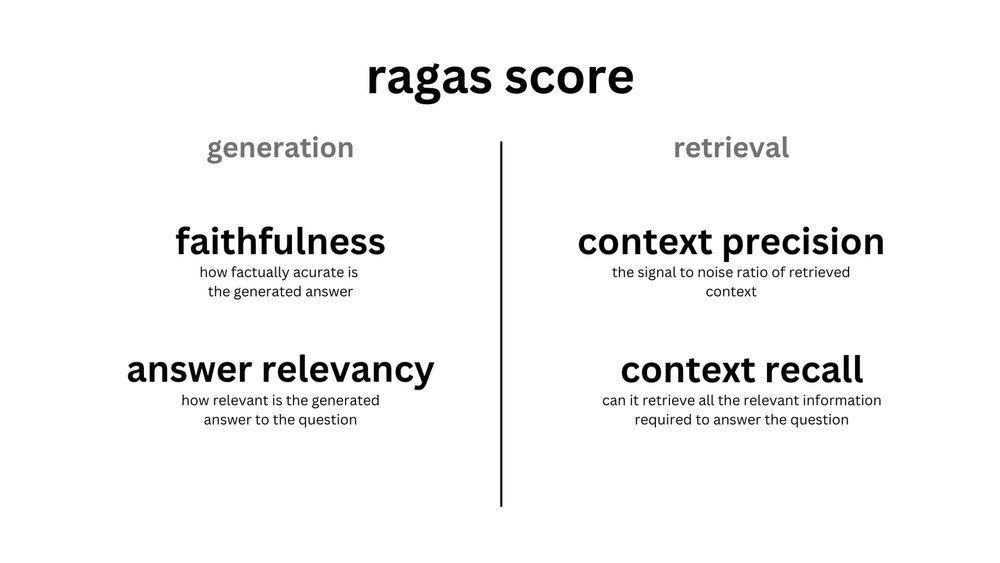

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [47]:
def data_preprocess(df):

    required_columns = ["question", "answer", "ground_truth", "contexts"]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError

    df["ground_truths"] = df["ground_truth"].apply(lambda x: [x])
    df["contexts"] = df["contexts"].apply(lambda x: x if isinstance(x, list) else [x])

    df = df[["question", "ground_truths", "answer", "contexts"]]
    return df


In [48]:
def answer_relevancy(df, llm, embed_model_name=EMBEDDING_MODEL_NAME, N=3):


    model = SentenceTransformer(embed_model_name)
    scores = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        generated_questions = []

        for _ in range(N):
            prompt = RAG_PROMPT_TEMPLATE.format(
                question="Сформулируй вопрос, на который данный текст является ответом. Верни только вопрос.",
                context=row["answer"]
            )
            gen_q = llm(prompt)[0]["generated_text"].strip()
            generated_questions.append(gen_q)


        gen_q_embeds = model.encode(generated_questions, normalize_embeddings=True)

        orig_q_embed = model.encode([row["question"]], normalize_embeddings=True)


        sim = cosine_similarity(gen_q_embeds, orig_q_embed).mean()
        scores.append(sim)

    df["relevancy_score"] = scores
    return float(np.mean(scores))


# Протестируйте ваш RAG (3 балла)

In [49]:
df_filtered = grouped[grouped['description'] != '']
df_filtered.head(1)

,City,Name,description,en_txt_combined,WikiData,Lon,Lat,image,num_photos,full_text
2,Владимир,église arménienne de Vladimir,Армянская церковь в г. Владимир России,a close up of a planet with a star in the back...,Q18331756,40.456497,56.154667,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,29,église arménienne de Vladimir (Владимир). Армя...


In [51]:
total = 15
rows = []

for _, row in tqdm(df_filtered.sample(total, random_state=42).iterrows(), total=total):

    prompt_q = RAG_PROMPT_TEMPLATE.format(
        question="На основе описания ниже сформулируй один конкретный вопрос, на который это описание даёт ответ. Верни только вопрос.",
        context=row["description"]
    )
    question = READER_LLM(prompt_q)[0]["generated_text"].strip()

    answer, relevant_docs = answer_with_rag(
        question=question,
        llm=READER_LLM,
        knowledge_index=KNOWLEDGE_VECTOR_DATABASE,
        reranker=RERANKER,
    )

    rows.append({
        "question": question,
        "answer": answer,
        "ground_truth": row["description"],
        "contexts": [doc for doc in relevant_docs],
    })

dataset = pd.DataFrame(rows)


  0%|          | 0/15 [00:00<?, ?it/s]

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Retrieving documents...
=> Reranking documents...



100%|██████████| 1/1 [00:00<00:00, 10.46it/s]
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Generating answer...


...

=> Generating answer...


Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Retrieving documents...
=> Reranking documents...



100%|██████████| 1/1 [00:00<00:00, 23.43it/s]
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=> Generating answer...


In [52]:
for i in range(3):
    print(f"--- Пример {i+1} ---")
    print(f"Q: {dataset['question'][i]}")
    print(f"A: {dataset['answer'][i][:200]}")
    print(f"GT: {dataset['ground_truth'][i]}")
    print()


--- Пример 1 ---
Q: Назовите название лицея № 82?
A: Название лицея № 82 — Лицей № 82 "Школа баррикад" (Нижний Новгород).
GT: Лицей № 82 "Школа баррикад"

--- Пример 2 ---
Q: Какая организация указана в данном описании?
A: Указаны несколько организаций:

1. Уральский государственный колледж имени И.И. Ползунова (Екатеринбург)
2. Ярославский филиал Военно-космической академии имени А. Ф. Можайского (Ярославль)
3. Церковь
GT: ГАУЗ ЯО Клиническая больница скорой медицинской помощи имени Н. В. Соловьёва

--- Пример 3 ---
Q: Что такое Троицкая церковь?
A: Троицкая церковь находится в Владимире и представляет собой крупное красное здание с часовой башней.
GT: Троицкая церковь



In [53]:
score = answer_relevancy(dataset, READER_LLM)
print(f"Answer Relevancy: {score:.3f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/15 [00:00<?, ?it/s]

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Answer Relevancy: 0.924


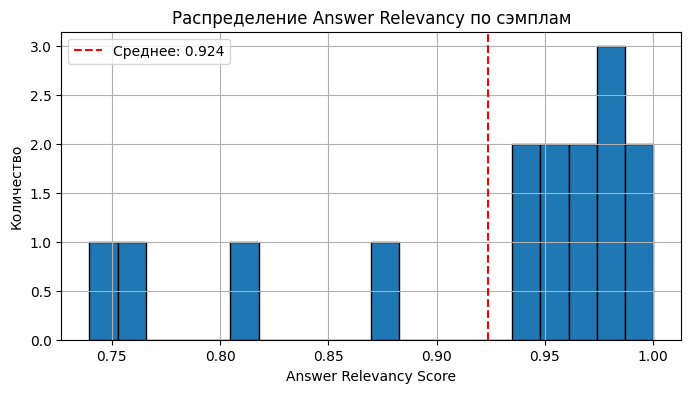

In [54]:
fig, ax = plt.subplots(figsize=(8, 4))
dataset["relevancy_score"].hist(bins=20, ax=ax, edgecolor="black")
ax.axvline(x=dataset["relevancy_score"].mean(), color="red", linestyle="--", label=f"Среднее: {dataset['relevancy_score'].mean():.3f}")
ax.set_xlabel("Answer Relevancy Score")
ax.set_ylabel("Количество")
ax.set_title("Распределение Answer Relevancy по сэмплам")
ax.legend()
plt.show()


In [55]:
worst = dataset.sort_values("relevancy_score").head(5)
for _, r in worst.iterrows():
    print(f"Score: {r['relevancy_score']:.3f}")
    print(f"  Q: {r['question']}")
    print(f"  A: {r['answer'][:150]}")
    print(f"  GT: {r['ground_truth'][:100]}")
    print("---")


Score: 0.740
  Q: Какой стадион находится в Екатеринбурге?
  A: Информации о стадионе в контексте нет. Документы перечисляют различные достопримечательности и учреждения Екатеринбурга, но не упоминается ни один ста
  GT: стадион в Екатеринбурге
---
Score: 0.764
  Q: Какой дом принадлежал В. И. Смирнову?
  A: Информации о доме, принадлежащем В. И. Смирnovу, в предоставленном контексте нет. Данные документы относятся к другим достопримечательностям Нижнего Н
  GT: Дом В. И. Смирнова
---
Score: 0.818
  Q: Что такое Троицкая церковь?
  A: Троицкая церковь находится в Владимире и представляет собой крупное красное здание с часовой башней.
  GT: Троицкая церковь
---
Score: 0.870
  Q: Какое название имеет этот парк?
  A: Не могу дать точный ответ, так как в вопросе не указано конкретное название парка. Однако, исходя из контекста, можно предположить, что это может быть
  GT: Парк Кулибина
---
Score: 0.946
  Q: Какой музей представлен в данном описании?
  A: На основе предоставленных данных не